In [37]:
import pandas as pd
try:
    # Try reading the file
    data = pd.read_csv("products_report.csv")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")

print("File read successfully.")
print(data)

File read successfully.
    Index                                   Name  \
0       1   Compact Printer Air Advanced Digital   
1       2                                 Tablet   
2       3                   Smart Blender Cooker   
3       4           Advanced Router Rechargeable   
4       5           Portable Mouse Monitor Phone   
..    ...                                    ...   
95     96                                 Router   
96     97     Fast Thermostat Microphone Scooter   
97     98  Eco Heater Toaster Stove Silent Sense   
98     99               Clean Blender Scale Lite   
99    100                             Smart Lamp   

                                          Description  \
0       Situation organization these memory much off.   
1         Discussion loss politics free one thousand.   
2                                   No situation per.   
3                     For force gas energy six laugh.   
4   Feeling back religious however author room sci...   
..       

In [8]:
# displaying the first 5 rows
print(data.head())

   Index                                  Name  \
0      1  Compact Printer Air Advanced Digital   
1      2                                Tablet   
2      3                  Smart Blender Cooker   
3      4          Advanced Router Rechargeable   
4      5          Portable Mouse Monitor Phone   

                                         Description  \
0      Situation organization these memory much off.   
1        Discussion loss politics free one thousand.   
2                                  No situation per.   
3                    For force gas energy six laugh.   
4  Feeling back religious however author room sci...   

                        Brand            Category  Price Currency  Stock  \
0     Garner, Boyle and Flynn  Books & Stationery    265      USD    774   
1                 Mueller Inc    Shoes & Footwear    502      USD     81   
2  Lawson, Keller and Winters  Kitchen Appliances    227      USD    726   
3          Gallagher and Sons  Kitchen Appliances    121  

In [10]:
# checking the structure of datasetsby their datatypes
print("Dataset Info:\n")
print(data.info())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Index         100 non-null    int64 
 1   Name          100 non-null    object
 2   Description   100 non-null    object
 3   Brand         100 non-null    object
 4   Category      100 non-null    object
 5   Price         100 non-null    int64 
 6   Currency      100 non-null    object
 7   Stock         100 non-null    int64 
 8   EAN           100 non-null    int64 
 9   Color         100 non-null    object
 10  Size          100 non-null    object
 11  Availability  100 non-null    object
 12  Internal ID   100 non-null    int64 
dtypes: int64(5), object(8)
memory usage: 10.3+ KB
None


In [11]:
# checking for missing values
print("\nMissing values:\n")
print(data.isnull())


Missing values:

    Index   Name  Description  Brand  Category  Price  Currency  Stock    EAN  \
0   False  False        False  False     False  False     False  False  False   
1   False  False        False  False     False  False     False  False  False   
2   False  False        False  False     False  False     False  False  False   
3   False  False        False  False     False  False     False  False  False   
4   False  False        False  False     False  False     False  False  False   
..    ...    ...          ...    ...       ...    ...       ...    ...    ...   
95  False  False        False  False     False  False     False  False  False   
96  False  False        False  False     False  False     False  False  False   
97  False  False        False  False     False  False     False  False  False   
98  False  False        False  False     False  False     False  False  False   
99  False  False        False  False     False  False     False  False  False   

    Color

In [12]:
cleaned_data = data.dropna()
print(cleaned_data.isnull().sum())


Index           0
Name            0
Description     0
Brand           0
Category        0
Price           0
Currency        0
Stock           0
EAN             0
Color           0
Size            0
Availability    0
Internal ID     0
dtype: int64


In [3]:
# computing basic statics of numerical columns in cleaned data
stats=cleaned_data.describe()
print(stats)

            Index      Price       Stock           EAN  Internal ID
count  100.000000  100.00000  100.000000  1.000000e+02   100.000000
mean    50.500000  451.19000  545.710000  4.876267e+12    49.340000
std     29.011492  281.60911  266.716863  2.918084e+12    28.078253
min      1.000000    1.00000   10.000000  5.246382e+08     3.000000
25%     25.750000  230.75000  347.500000  2.062323e+12    25.000000
50%     50.500000  407.50000  575.500000  4.875720e+12    48.000000
75%     75.250000  679.00000  749.250000  7.676943e+12    74.500000
max    100.000000  999.00000  998.000000  9.921752e+12    99.000000


In [11]:
# grouping multiple columns and calculating the mean of each numerical group
mean_price_grouped = cleaned_data.groupby(['Name', 'Brand', 'Category'], as_index=False)['Price'].mean()
print(mean_price_grouped)

                                                 Name  \
0         Advanced Camera Heater Webcam X Ultra Prime   
1                  Advanced Freezer Advanced Advanced   
2                      Advanced Microphone Cooler Eco   
3                        Advanced Router Rechargeable   
4                                   Automatic Blender   
..                                                ...   
95              Wireless Powerbank 360 Advanced Ultra   
96                        Wireless Scooter Clean Mini   
97  Wireless Tablet Router Printer Wireless Premiu...   
98  Wireless Watch Tablet Printer Automatic Eco Sense   
99                        Wireless Webcam Stove Grill   

                            Brand            Category  Price  
0                   Cervantes Ltd     Office Supplies  224.0  
1                        Gill LLC     Office Supplies  489.0  
2   Morales, Weaver and Fernandez         Smartphones  904.0  
3              Gallagher and Sons  Kitchen Appliances  121.0  


In [13]:
# Brands with the highest price
cleaned_data.groupby('Brand')['Price'].mean().sort_values(ascending=False)


Brand
Zimmerman, Barr and Davis       999.0
Lewis Ltd                       998.0
Larson-Spence                   985.0
Ali-Oliver                      982.0
Barker-Murphy                   982.0
                                ...  
Nichols, Howe and Miller         30.0
Elliott, Mcfarland and Duran     12.0
Barry PLC                         5.0
Vazquez-Smith                     3.0
Irwin LLC                         1.0
Name: Price, Length: 100, dtype: float64

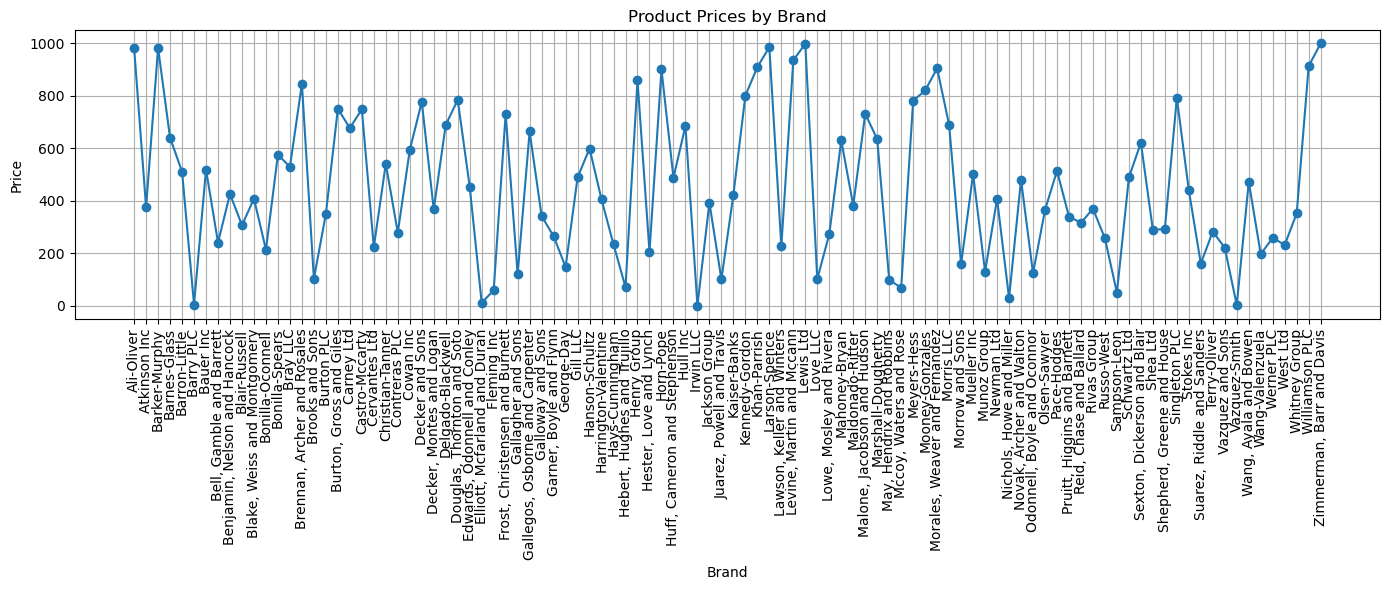

In [22]:
import matplotlib.pyplot as plt
# Sort data by Brand to keep the plot organized
df_sorted = cleaned_data.sort_values(by='Brand')


# Plot line chart of each product's price by brand
plt.figure(figsize=(14, 6))
plt.plot(df_sorted['Brand'], df_sorted['Price'], marker='o', linestyle='-')
plt.xticks(rotation=90)
plt.title('Product Prices by Brand')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()


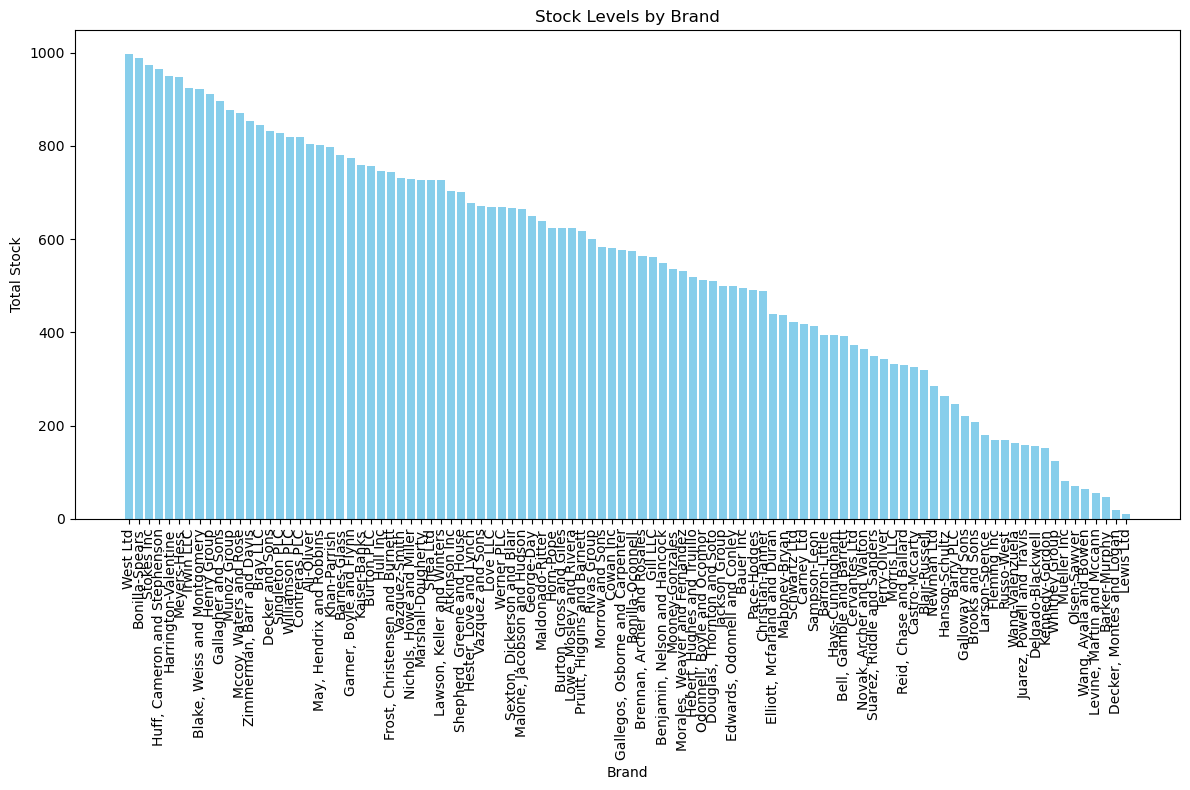

In [24]:
brand_stock = cleaned_data.groupby('Brand')['Stock'].sum().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 8))
plt.bar(brand_stock.index, brand_stock.values, color='skyblue')
plt.title('Stock Levels by Brand')
plt.xlabel('Brand')
plt.ylabel('Total Stock')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

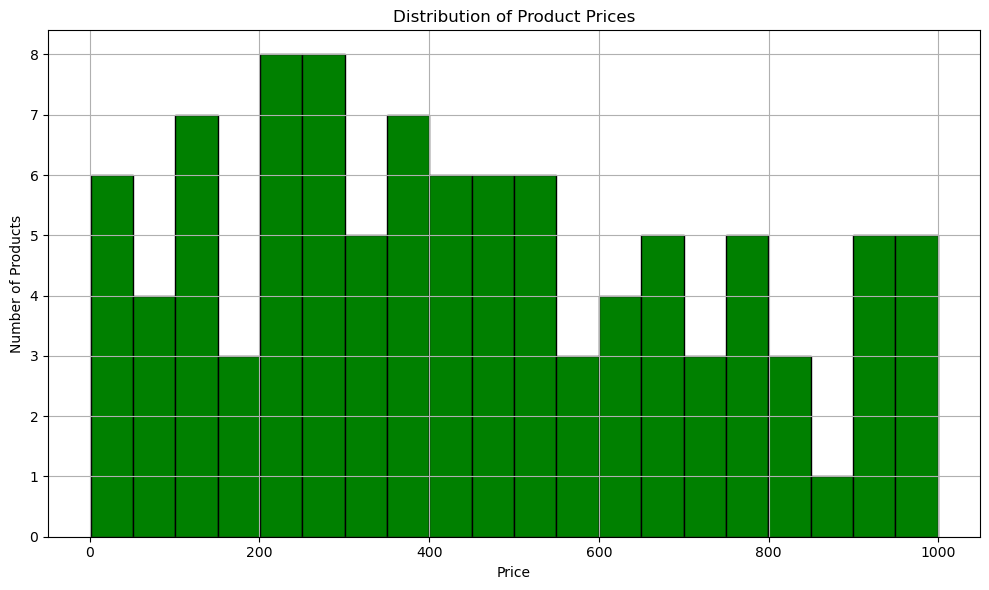

In [26]:
# Create histogram of product prices
plt.figure(figsize=(10, 6))
plt.hist(cleaned_data['Price'], bins=20, color='green', edgecolor='black')
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Number of Products')
plt.grid(True)
plt.tight_layout()
plt.show()

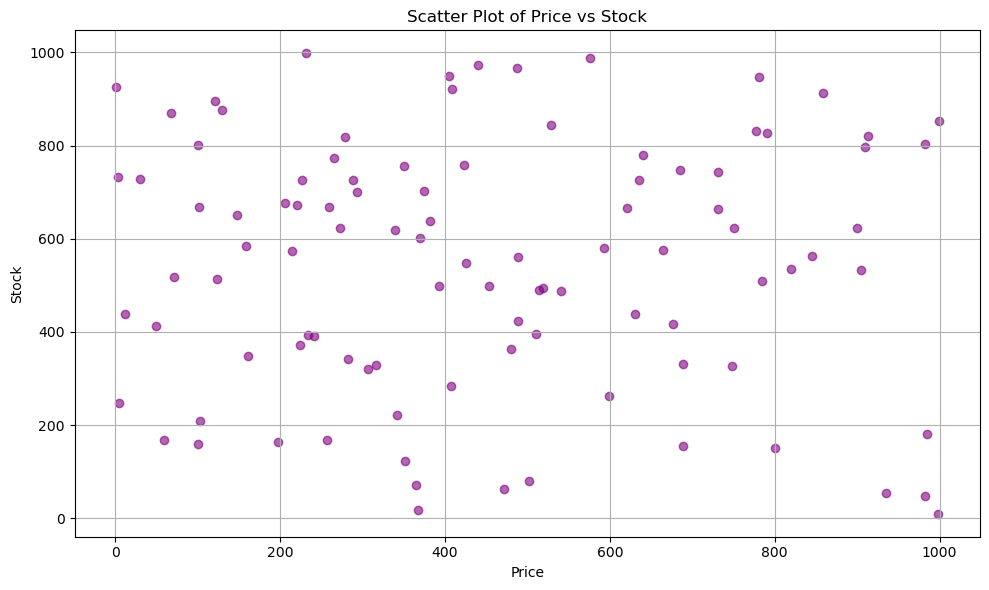

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(cleaned_data['Price'], cleaned_data['Stock'], color='purple', alpha=0.6)
plt.title('Scatter Plot of Price vs Stock')
plt.xlabel('Price')
plt.ylabel('Stock')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_252/1445842480.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


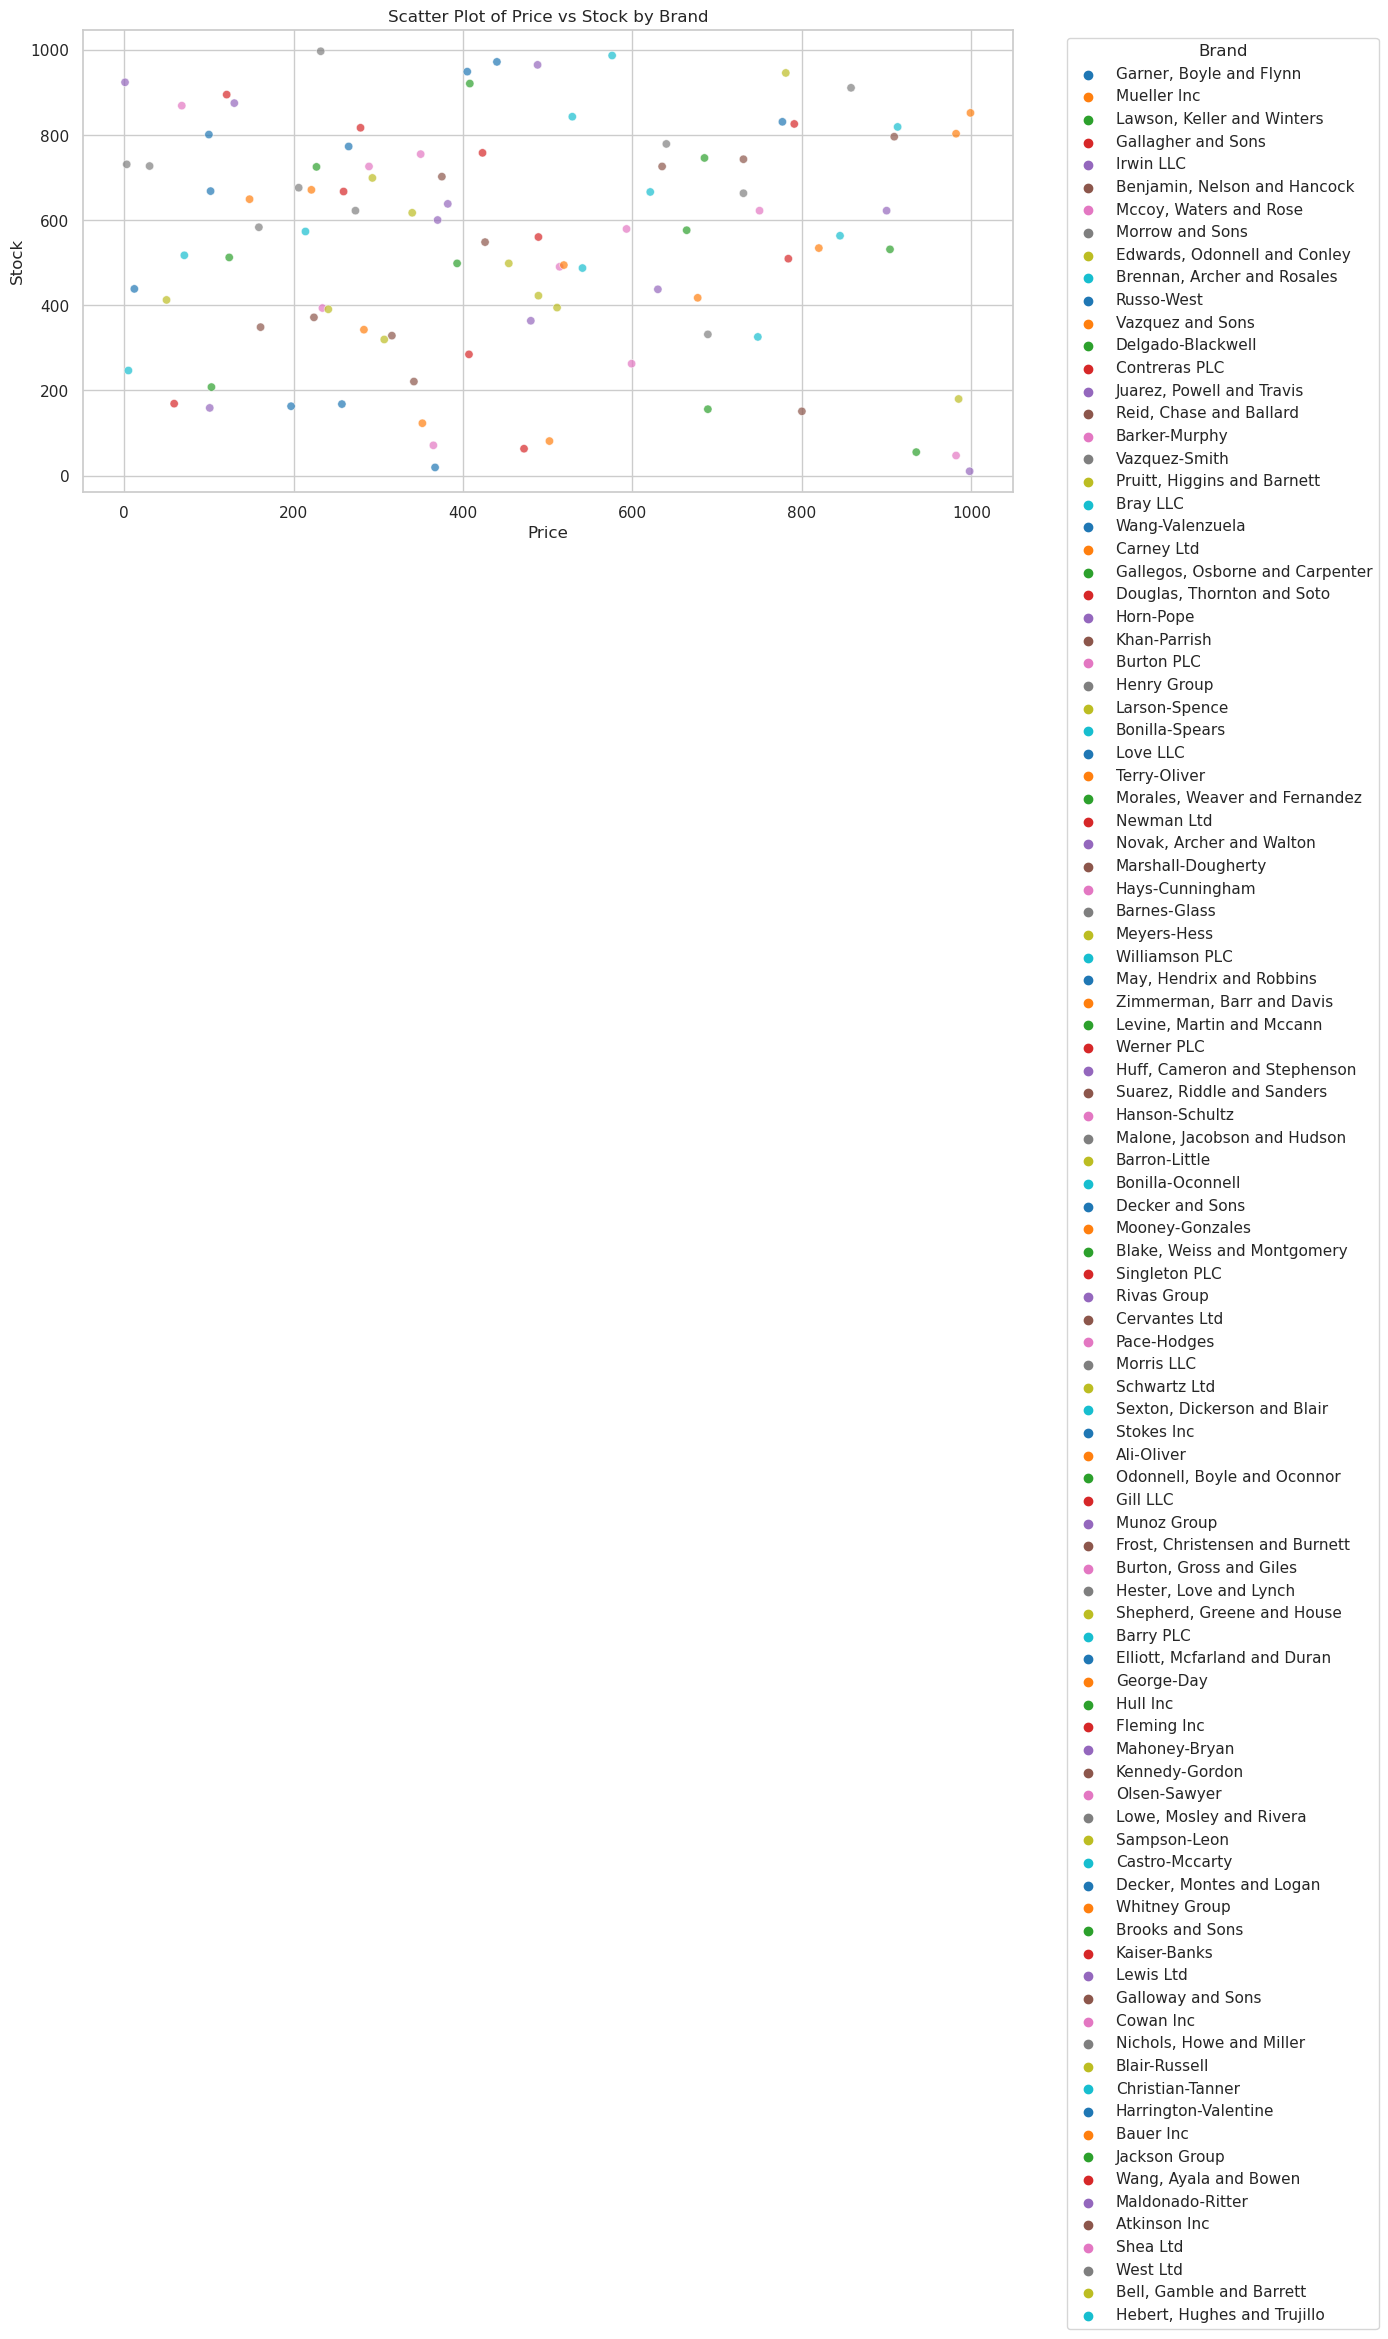

In [31]:
# using seaborn to plot a graph 
# Set plot style
import seaborn as sns
sns.set(style="whitegrid")

# Create scatter plot with color-coded brands
plt.figure(figsize=(12, 6))
sns.scatterplot(data=cleaned_data, x='Price', y='Stock', hue='Brand', palette='tab10', alpha=0.7)

plt.title('Scatter Plot of Price vs Stock by Brand')
plt.xlabel('Price')
plt.ylabel('Stock')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()
plt.show()